**Import Dataset**

Model: MobileNetV2 Transfer Learning


Dataset: Fire/Non-Fire Images


Accuracy: 93.97%


Techniques: Augmentation + Class Weights

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phylake1337/fire-dataset")

print("Path to dataset files:", path)

100%|██████████| 387M/387M [00:02<00:00, 154MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/phylake1337/fire-dataset/versions/1


**Import libraries**

In [ ]:
import tensorflow as tf
import kagglehub
import os
import numpy as np


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


**# Dataset Download and Setup**

In [ ]:
path = kagglehub.dataset_download("phylake1337/fire-dataset")

print(path)

Using Colab cache for faster access to the 'fire-dataset' dataset.
/kaggle/input/fire-dataset


**# Detect Dataset Folder and Classes**

In [ ]:
for root, dirs, files in os.walk(path):
    if len(dirs) >= 2:
        dataset_dir = root
        break

print("Dataset Directory:")
print(dataset_dir)

print("\nClasses:")
print(os.listdir(dataset_dir))

Dataset Directory:
/kaggle/input/fire-dataset/fire_dataset

Classes:
['non_fire_images', 'fire_images']


**# Data Augmentation and Data Generators**

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=30,
    zoom_range=0.3,

    width_shift_range=0.2,
    height_shift_range=0.2,

    shear_range=0.2,

    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

print(train_generator.class_indices)

Found 800 images belonging to 2 classes.
Found 199 images belonging to 2 classes.
{'fire_images': 0, 'non_fire_images': 1}


**# Build MobileNetV2 Model**

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**# Define Training Callbacks**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

**# Handle Class Imbalance using Class Weights**

In [ ]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(0.6622516556291391), 1: np.float64(2.0408163265306123)}


**# Train the Model**

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.7287 - loss: 0.5445 - val_accuracy: 0.8693 - val_loss: 0.3258 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.8963 - loss: 0.2843 - val_accuracy: 0.9397 - val_loss: 0.2059 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9125 - loss: 0.2254 - val_accuracy: 0.9146 - val_loss: 0.2090 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9238 - loss: 0.1684
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
25/25 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.9262 - loss: 0.1819 - val_accuracy: 0.8945 - val_loss: 0.2179 - learning_rate: 0.0010
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9200 - loss: 0.2109 - val_accuracy: 0.9045 - val_loss: 0.2220 - learning_rate: 2.0000e-04


**# Evaluate Model Performance**

In [ ]:
loss, accuracy = model.evaluate(val_generator)

print(f"Validation Accuracy = {accuracy*100:.2f}%")
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = val_generator.classes

y_pred = model.predict(val_generator)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

print(cm)
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(val_generator.class_indices.keys())
    )
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9045 - loss: 0.2424
Validation Accuracy = 90.45%
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
[[107  44]
 [ 35  13]]
                 precision    recall  f1-score   support

    fire_images       0.75      0.71      0.73       151
non_fire_images       0.23      0.27      0.25        48

       accuracy                           0.60       199
      macro avg       0.49      0.49      0.49       199
   weighted avg       0.63      0.60      0.61       199



**# Fire Detection Prediction**

Image Path: /kaggle/input/fire-dataset/fire_dataset/fire_images/fire.663.png


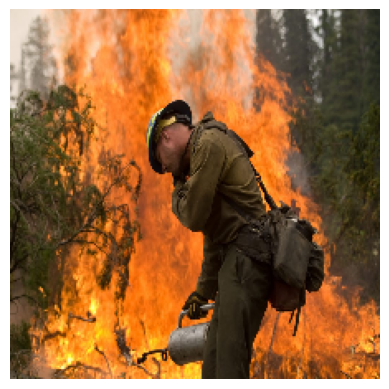

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Raw Prediction: 0.033517204
🔥 Fire Detected


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

image_paths = []

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, file))

img_path = random.choice(image_paths)

print("Image Path:", img_path)


img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis("off")
plt.show()


img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0


prediction = model.predict(img_array)[0][0]

print("Raw Prediction:", prediction)


if prediction < 0.5:
    print("🔥 Fire Detected")
else:
    print("✅ No Fire")

In [ ]:
model.save("fire_detection_model.keras")

In [ ]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# Load trained model
model = tf.keras.models.load_model("fire_detection_model.keras")

st.set_page_config(
    page_title="Fire Detection AI",
    page_icon="🔥"
)

st.title("🔥 Fire Detection System")
st.write("Upload an image to detect fire.")

uploaded_file = st.file_uploader(
    "Choose an image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Image",
        use_container_width=True
    )

    # Preprocessing
    img = image.resize((224,224))

    img_array = np.array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Prediction
    prediction = model.predict(img_array)[0][0]

    confidence = max(
        prediction,
        1-prediction
    ) * 100

    st.write(
        f"Confidence: {confidence:.2f}%"
    )

    # IMPORTANT:
    # Check train_generator.class_indices
    if prediction < 0.5:
        st.error("🔥 Fire Detected")
    else:
        st.success("✅ No Fire Detected")

    st.write(
        f"Raw Prediction: {prediction:.4f}"
    )

Overwriting app.py


In [ ]:
!pip install -q streamlit pyngrok

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!pip install streamlit -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

(Reading database ... 118247 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.6.1) over (2026.6.1) ...
Setting up cloudflared (2026.6.1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!streamlit run app.py >/content/log.txt 2>&1 &

In [ ]:
!cloudflared tunnel --url http://localhost:8501

2026-06-24T14:34:36Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-24T14:34:36Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-24T14:34:40Z INF +--------------------------------------------------------------------------------------------+
2026-06-24T14:34:40Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-24T14:34:40Z INF |  https://satisfied-revolution-blocking-serving.tryclou

In [ ]:
!cat /content/log.txt



2026-06-24 14:18:05.817 Uvicorn server started on 0.0.0.0:8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.58.71.40:8502

  Stopping...
